In [1]:
from astropy import units as u
from astropy.coordinates import SkyCoord

import matplotlib.pyplot as plt
from IPython.display import display
from gammapy.data import EventList
from gammapy.datasets import Datasets, MapDataset
from gammapy.irf import EDispKernelMap, PSFMap
from gammapy.maps import Map, MapAxis, WcsGeom
from gammapy.modeling import Fit
from matplotlib.patches import Circle
from gammapy.modeling.models import (
    Models,
    PointSpatialModel,
    PowerLawNormSpectralModel,
    PowerLawSpectralModel,
    SkyModel,
    TemplateSpatialModel,
    create_fermi_isotropic_diffuse_model,
)
from astropy.table import vstack
from gammapy.data import EventList
from gammapy.catalog import SourceCatalog4FGL

import yaml
from fermipy.gtanalysis import GTAnalysis
from fermipy.plotting import ROIPlotter, SEDPlotter

catalog_4fgl = SourceCatalog4FGL("/Users/vdk/shared/fermibottle/gll_psc_v35.fit")

In [18]:
# Create a GTAnalysis object from the configuration file.
gta = GTAnalysis('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/fermi_config_sgr1900_15deg_region.yaml', logging={'verbosity': 3})

2025-05-01 13:38:12 INFO    GTAnalysis.__init__(): 
--------------------------------------------------------------------------------
fermipy version 1.3.1 
ScienceTools version 2.2.0


In [19]:
gta.config

{'logging': {'prefix': '', 'chatter': 3, 'verbosity': 3},
 'fileio': {'outdir': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region',
  'scratchdir': '/scratch',
  'workdir': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region',
  'logfile': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/fermipy.log',
  'savefits': True,
  'workdir_regex': ['\\.fits$|\\.fit$|\\.xml$|\\.npy$'],
  'outdir_regex': ['\\.fits$|\\.fit$|\\.xml$|\\.npy$|\\.png$|\\.pdf$|\\.yaml$'],
  'usescratch': False},
 'optimizer': {'optimizer': 'MINUIT',
  'tol': 0.001,
  'max_iter': 100,
  'init_lambda': 0.0001,
  'retries': 3,
  'min_fit_quality': 2,
  'verbosity': 0},
 'binning': {'projtype': 'WCS',
  'proj': 'AIT',
  'coordsys': 'GAL',
  'npix': None,
  'roiwidth': 15.0,
  'binsz': 0.05,
  'binsperdec': 8.0,
  'enumbins': None,
  'hpx_ordering_scheme': 'RING',
  'hpx_or

In [20]:
gta.setup()

2025-05-01 13:38:12 INFO    GTAnalysis.setup(): Running setup.
2025-05-01 13:38:12 INFO    GTBinnedAnalysis.setup(): Running setup for component 00
2025-05-01 13:38:12 INFO    GTBinnedAnalysis._select_data(): Skipping data selection.
2025-05-01 13:38:12 INFO    GTBinnedAnalysis._create_ltcube(): Skipping LT Cube.
2025-05-01 13:38:13 INFO    GTBinnedAnalysis._create_expcube(): Skipping gtexpcube.
Set MJD-OBS to 54682.655283 from DATE-OBS.
Set MJD-END to 60774.984781 from DATE-END'. [astropy.wcs.wcs]
2025-05-01 13:38:13 INFO    GTBinnedAnalysis._create_srcmaps(): Skipping gtsrcmaps.
2025-05-01 13:38:13 INFO    GTBinnedAnalysis.setup(): Finished setup for component 00
2025-05-01 13:38:13 INFO    GTBinnedAnalysis._create_binned_analysis(): Creating BinnedAnalysis for component 00.
2025-05-01 13:38:19 INFO    GTAnalysis.setup(): Initializing source properties
2025-05-01 13:38:19 INFO    GTAnalysis.setup(): Finished setup.


In [21]:
gta.print_model()

2025-05-01 13:38:19 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1908.6+0915e     0.000   1.276  1.09e-05   2.20       nan      1631.6     
4FGL J1910.2+0904c     0.430   0.394  9.92e-06   2.29       nan      1715.9     
4FGL J1911.0+0905      0.619   0.756  5.62e-05   2.21       nan     11385.2     
4FGL J1911.8+0903c     0.808   0.372  3.87e-06   2.15       nan       529.0     
4FGL J1912.0+0927      0.869   0.320  3.88e-06   2.95       nan      1254.9     
4FGL J1908.7+0812      1.056   1.845  6.41e-06   3.36       nan      2301.0     
4FGL J1913.3+0905      1.183   0.902  7.57e-06   3.19       nan      2261.8     
4FGL J1912.7+0957      1.226   0.500  5.24e-06   3.04       nan      1745.5     
4FGL J1911.7+1014c     1.241   0.441   2.7e-06   3.19       nan       936.9     
4FGL J1913.3+1019      1.586   0.331  7.51e-06   2.17 

2025-05-01 13:38:19 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/initial_00.xml...
2025-05-01 13:38:19 INFO    GTAnalysis.write_fits(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/initial.fits...
2025-05-01 13:38:21 INFO    GTBinnedAnalysis.write_model_map(): Generating model map for component 00.
2025-05-01 13:38:23 INFO    GTAnalysis.write_roi(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/initial.npy...


<Figure size 2000x2000 with 0 Axes>

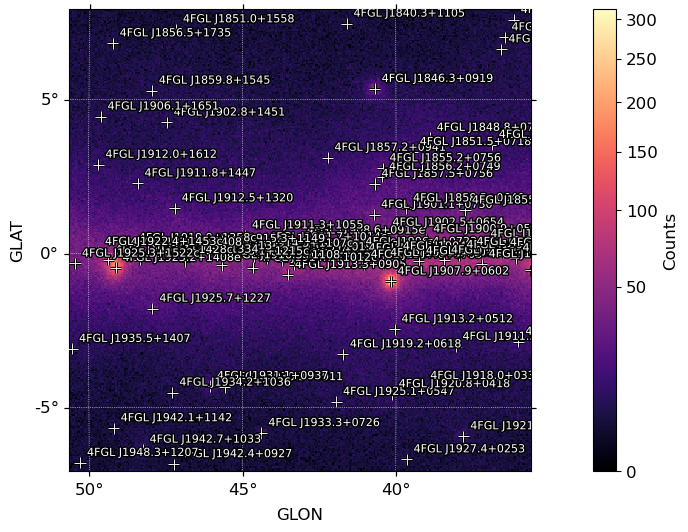

In [22]:
plt.figure(figsize=(20, 20))
gta.write_roi('initial',make_plots=True,save_model_map=True)
plt.show()

## Free parameters of the sources in the region 3 degrees around the source

In [23]:
gta.free_sources(free=False)
gta.free_sources(skydir=gta.roi[gta.roi.sources[0].name].skydir,distance=[3.0],free=True)

2025-05-01 13:38:27 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1908.6+0915e    : ['Prefactor', 'Index']
2025-05-01 13:38:27 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1910.2+0904c    : ['Prefactor', 'Index']
2025-05-01 13:38:27 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1911.0+0905     : ['norm', 'alpha', 'beta']
2025-05-01 13:38:27 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1911.8+0903c    : ['Prefactor', 'Index']
2025-05-01 13:38:27 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1912.0+0927     : ['norm', 'alpha', 'beta']
2025-05-01 13:38:27 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1908.7+0812     : ['norm', 'alpha', 'beta']
2025-05-01 13:38:27 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1913.3+0905     : ['Prefactor', 'IndexS', 'ExpfactorS']
2025-05-01 13:38:27 INFO    GTAnalysis.free_source(): Freeing parameters for 4FGL J1912.7+0957     : ['norm'

In [25]:
gta.fit()

2025-05-01 13:38:32 INFO    GTAnalysis.fit(): Starting fit.
/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)
2025-05-01 13:41:28 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2025-05-01 13:41:28 INFO    GTAnalysis.fit(): LogLike:   222358.043 DeltaLogLike:     1270.183 


{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 1270.1830782748293,
 'edm': 0.0014267307537630485,
 'loglike': 222358.04268841515,
 'covariance': array([[ 2.63853745e-02,  3.62108805e-02,  1.93355498e-03, ...,
         -1.37739368e-05, -9.39010449e-06,  8.14783484e-05],
        [ 3.62108805e-02,  1.14171529e-01, -3.12001558e-02, ...,
         -1.39638122e-05, -1.45513151e-05,  1.01945420e-04],
        [ 1.93355498e-03, -3.12001558e-02,  4.19964051e-02, ...,
         -3.89362247e-06, -3.00002487e-06, -1.43319813e-05],
        ...,
        [-1.37739368e-05, -1.39638122e-05, -3.89362247e-06, ...,
          2.70450556e-06,  1.45263624e-06,  2.59232156e-05],
        [-9.39010449e-06, -1.45513151e-05, -3.00002487e-06, ...,
          1.45263624e-06,  2.88712849e-06, -2.42367581e-05],
        [ 8.14783484e-05,  1.01945420e-04, -1.43319813e-05, ...,
          2.59232156e-05, -2.42367581e-05,  1.89186022e-03]]),
 'correlation': array([[ 1.        ,  0.6597487 ,  0.0580856

In [26]:
gta.print_model()

2025-05-01 13:41:28 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1908.6+0915e     0.000   1.220  9.88e-06   2.25     65.63      1607.4    *
4FGL J1910.2+0904c     0.430   0.413  1.02e-05   2.38    238.11      2004.6    *
4FGL J1911.0+0905      0.619   0.692  5.41e-05   2.19   6336.27     10391.1    *
4FGL J1911.8+0903c     0.808   0.531  5.66e-06   2.34     70.56      1051.3    *
4FGL J1912.0+0927      0.869   0.325  3.89e-06   2.74     83.61      1168.3    *
4FGL J1908.7+0812      1.056   1.712  6.59e-06   3.19    230.42      2306.6    *
4FGL J1913.3+0905      1.183   0.784  6.33e-06   3.28    323.85      1822.6    *
4FGL J1912.7+0957      1.226   0.488  4.86e-06   2.85    148.94      1515.0    *
4FGL J1911.7+1014c     1.241   0.332  3.26e-06   2.97     47.12       847.1    *
4FGL J1913.3+1019      1.586   0.326  7.33e-06   2.18 

In [27]:
plt.clf()
tsmap_postfit = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True)

2025-05-01 13:41:28 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-01 13:41:31 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-01 13:42:34 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-01 13:42:36 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/TSmap_start_pointsource_powerlaw_2.00_tsmap.npy
2025-05-01 13:42:36 INFO    GTAnalysis.tsmap(): Execution time: 68.39 s


<Figure size 640x480 with 0 Axes>

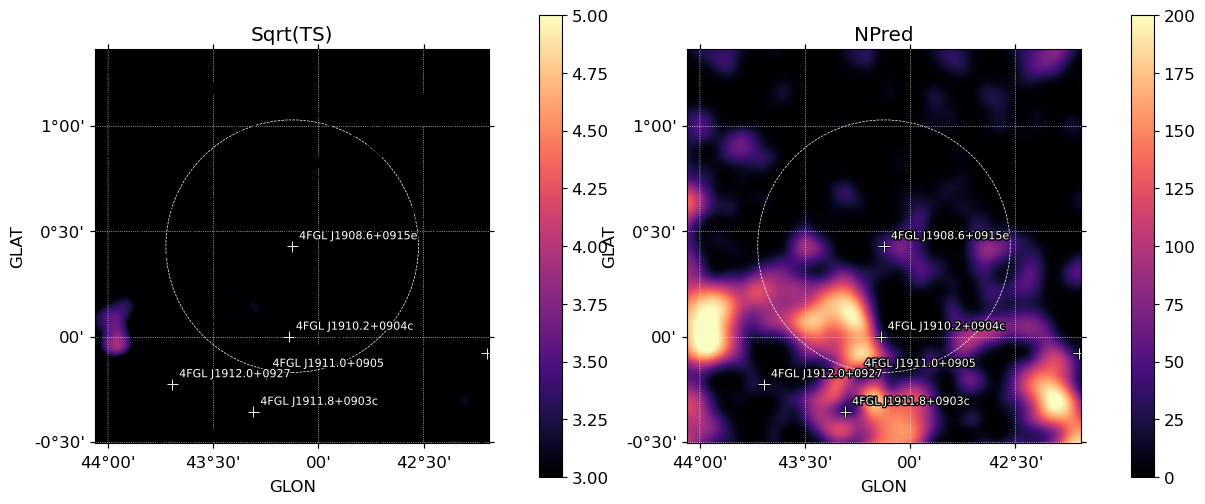

In [28]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_postfit['sqrt_ts'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',levels=[0,3,5],vmin=3,vmax=5,subplot=121,cmap='magma', zoom = 8)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_postfit['npred'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 8)
plt.gca().set_title('NPred')
plt.show()

In [ ]:
plt.clf()
tsmap_postfit_no_source = gta.tsmap(prefix='TSmap_start',make_plots=True,write_fits=True,write_npy=True, exclude_sources=gta.roi[gta.roi.sources[0].name])

In [ ]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_postfit_no_source['sqrt_ts'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',levels=[0,3,5],vmin=3,vmax=5,subplot=121,cmap='magma', zoom = 8)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_postfit_no_source['npred'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 8)
plt.gca().set_title('NPred')
plt.show()

# Exclude the main source from the whole fit model

In [13]:
gta.delete_source('4FGL J1908.6+0915e')
gta.fit()

2025-05-01 13:20:45 INFO    GTAnalysis.delete_source(): Deleting source 4FGL J1908.6+0915e
2025-05-01 13:20:45 INFO    GTAnalysis.fit(): Starting fit.
/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/scipy/interpolate/_fitpack2.py:313: UserWarning: 
The maximal number of iterations maxit (set to 20 by the program)
allowed for finding a smoothing spline with fp=s has been reached: s
too small.
There is an approximation returned but the corresponding weighted sum
of squared residuals does not satisfy the condition abs(fp-s)/s < tol.
  warnings.warn(message)
2025-05-01 13:23:21 INFO    GTAnalysis.fit(): Fit returned successfully. Quality:   3 Status:   0
2025-05-01 13:23:21 INFO    GTAnalysis.fit(): LogLike:   222331.861 DeltaLogLike:        7.512 


{'fit_quality': 3,
 'fit_status': 0,
 'fit_success': True,
 'dloglike': 7.512106156675145,
 'edm': 0.0011352161634007388,
 'loglike': 222331.86059195944,
 'covariance': array([[ 2.67868044e-02,  3.66646334e-02,  1.84089441e-03, ...,
         -1.37187209e-05, -9.65298313e-06, -9.31947081e-05],
        [ 3.66646334e-02,  1.15001058e-01, -3.13605916e-02, ...,
         -1.38690836e-05, -1.47898989e-05, -1.14647863e-04],
        [ 1.84089441e-03, -3.13605916e-02,  4.20422497e-02, ...,
         -3.86028475e-06, -2.90129097e-06,  1.66551058e-05],
        ...,
        [-1.37187209e-05, -1.38690836e-05, -3.86028475e-06, ...,
          2.73115323e-06,  1.37871956e-06, -2.90332932e-05],
        [-9.65298313e-06, -1.47898989e-05, -2.90129097e-06, ...,
          1.37871956e-06,  2.88683309e-06,  2.69190176e-05],
        [-9.31947081e-05, -1.14647863e-04,  1.66551058e-05, ...,
         -2.90332932e-05,  2.69190176e-05,  2.04802012e-03]]),
 'correlation': array([[ 1.        ,  0.66059605,  0.05485617

In [14]:
plt.clf()
tsmap_no_sources = gta.tsmap(prefix='TSmap_no_sources',make_plots=True,write_fits=True,write_npy=True)

2025-05-01 13:23:21 INFO    GTAnalysis.tsmap(): Generating TS map
2025-05-01 13:23:25 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-05-01 13:24:32 INFO    GTAnalysis.tsmap(): Finished TS map
2025-05-01 13:24:35 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/TSmap_no_sources_pointsource_powerlaw_2.00_tsmap.npy
2025-05-01 13:24:35 INFO    GTAnalysis.tsmap(): Execution time: 73.39 s


<Figure size 640x480 with 0 Axes>

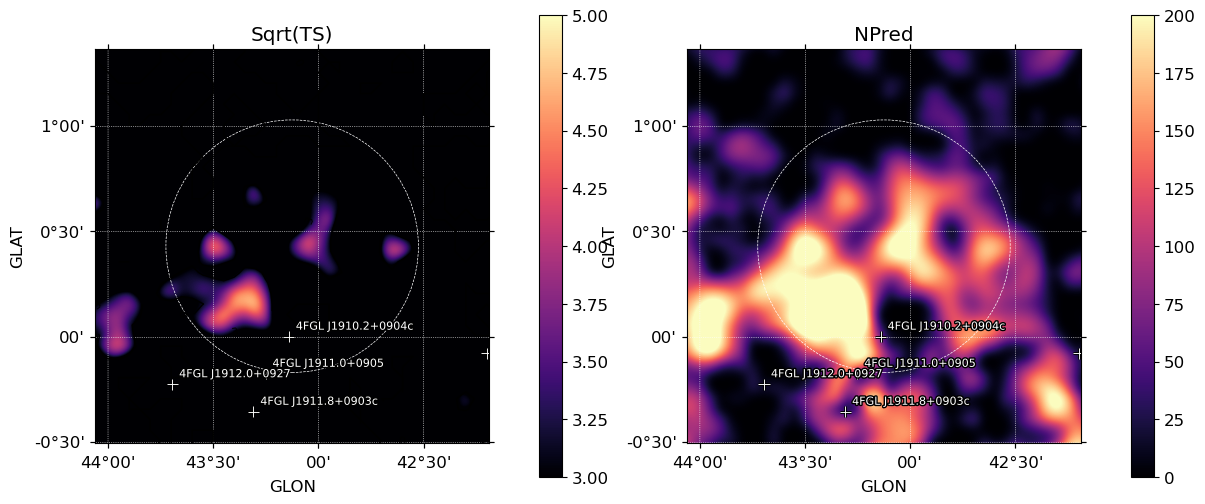

In [15]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_no_sources['sqrt_ts'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',levels=[0,3,5],vmin=3,vmax=5,subplot=121,cmap='magma', zoom = 8)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_no_sources['npred'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',vmin=0,vmax=200,subplot=122,cmap='magma', zoom = 8)
plt.gca().set_title('NPred')
plt.show()

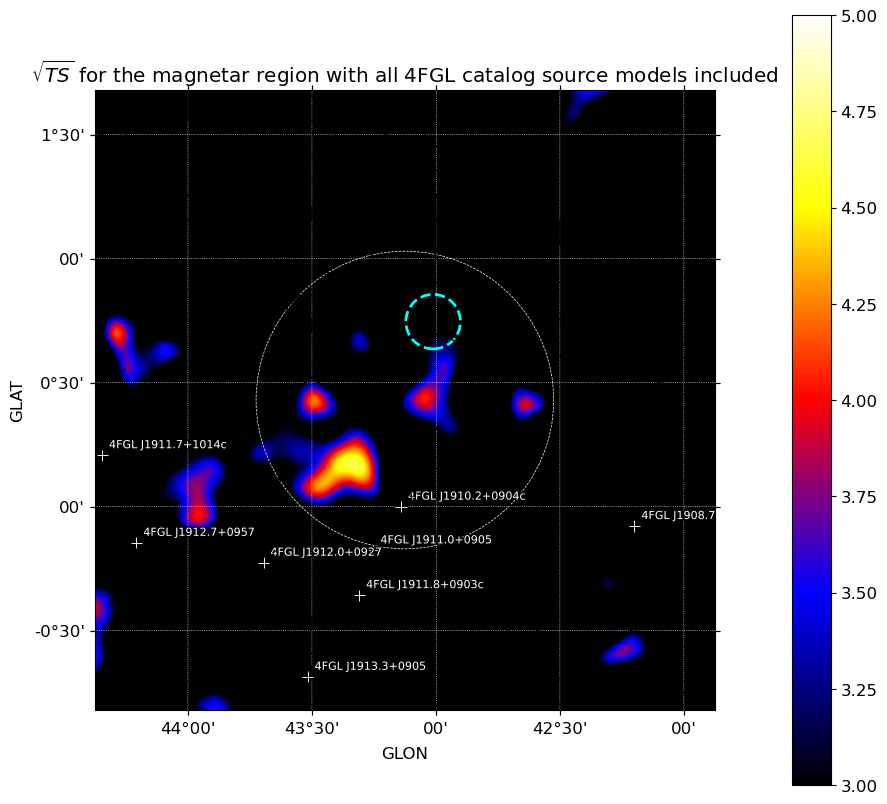

In [16]:
p = ROIPlotter(tsmap_no_sources['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=10.0)  # optional threshold for labeling

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")

plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=6,vmin=3,vmax=5, levels=[0,3,5])
p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')
plt.title("$\sqrt{TS}$ for the magnetar region with all 4FGL catalog source models included")
plt.show()

In [15]:
resid = gta.residmap('SMC_postfit',model={'SpatialModel' : 'PointSource', 'Index' : 2.0},write_fits=True,write_npy=True,make_plots=True)


2025-04-30 14:25:30 INFO    GTAnalysis.residmap(): Generating residual maps
2025-04-30 14:25:30 INFO    GTAnalysis.add_source(): Adding source residmap_testsource
2025-04-30 14:25:33 INFO    GTAnalysis.delete_source(): Deleting source residmap_testsource
2025-04-30 14:25:35 INFO    GTAnalysis.residmap(): Finished residual maps
2025-04-30 14:25:37 WARNING GTAnalysis.residmap(): Saving maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/SMC_postfit_pointsource_powerlaw_2.00_residmap.npy
2025-04-30 14:25:37 INFO    GTAnalysis.residmap(): Execution time: 6.31 s


<Figure size 640x480 with 0 Axes>

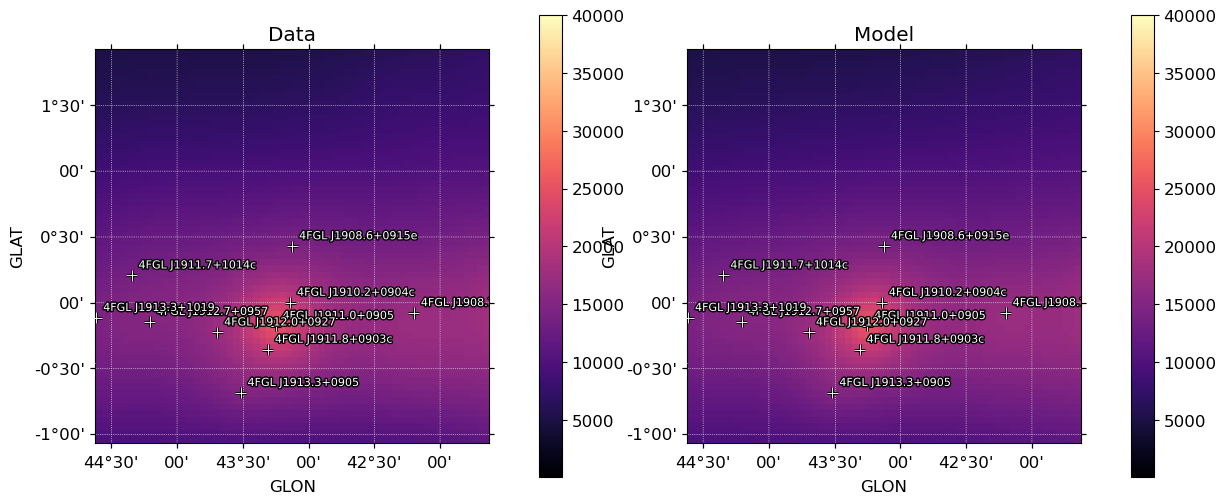

In [22]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(resid['data'],roi=gta.roi).plot(vmin=50,vmax=40000,subplot=121,cmap='magma', zoom = 5)
plt.gca().set_title('Data')
ROIPlotter(resid['model'],roi=gta.roi).plot(vmin=50,vmax=40000,subplot=122,cmap='magma', zoom = 5)
plt.gca().set_title('Model')
plt.show()

<Figure size 640x480 with 0 Axes>

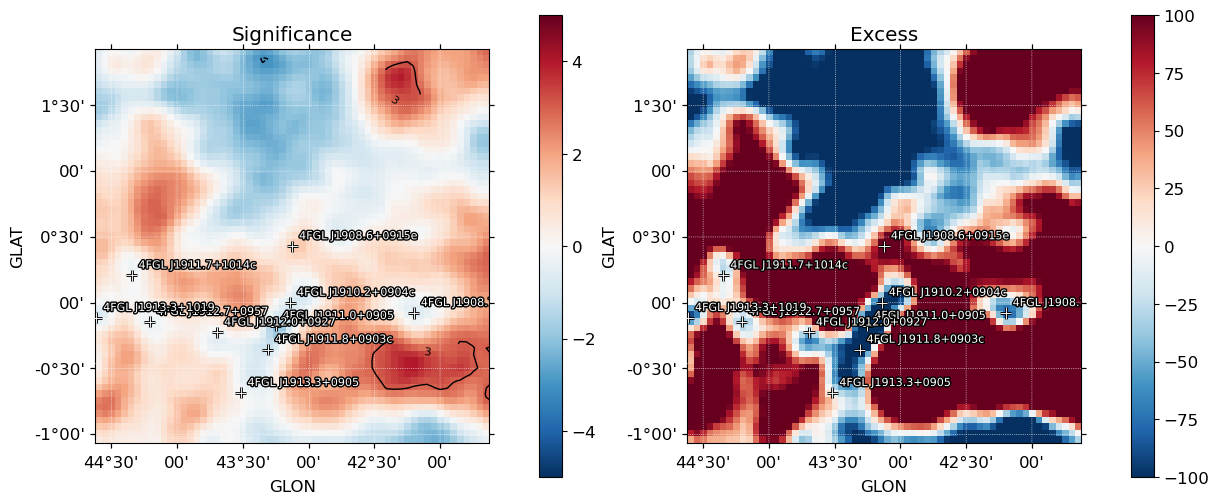

In [19]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(resid['sigma'],roi=gta.roi).plot(vmin=-5,vmax=5,levels=[-5,-3,3,5],subplot=121,cmap='RdBu_r', zoom = 5)
plt.gca().set_title('Significance')
ROIPlotter(resid['excess'],roi=gta.roi).plot(vmin=-100,vmax=100,subplot=122,cmap='RdBu_r', zoom = 5)
plt.gca().set_title('Excess')
plt.show()

In [26]:
gta.files

{'ccube': '/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/ccube.fits'}

## Read the results from npy file

In [52]:
gta.write_roi('fit0',make_plots=True)

2025-04-30 15:12:56 INFO    GTBinnedAnalysis.write_xml(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/fit0_00.xml...
2025-04-30 15:12:56 INFO    GTAnalysis.write_fits(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/fit0.fits...
2025-04-30 15:12:59 INFO    GTAnalysis.write_roi(): Writing /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/fit0.npy...


In [53]:
c = np.load('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/fit0.npy', allow_pickle=True).flat[0]

In [55]:
sorted(c['sources'].keys())

['4FGL J1830.1+0617',
 '4FGL J1832.7+0618',
 '4FGL J1834.3+0613',
 '4FGL J1840.3+1105',
 '4FGL J1846.0+0507',
 '4FGL J1846.3+0919',
 '4FGL J1848.8+0701',
 '4FGL J1851.0+1558',
 '4FGL J1851.5+0718',
 '4FGL J1855.2+0456',
 '4FGL J1855.2+0756',
 '4FGL J1856.2+0749',
 '4FGL J1856.5+1735',
 '4FGL J1857.2+0941',
 '4FGL J1857.5+0756',
 '4FGL J1857.7+0246e',
 '4FGL J1857.9+0313c',
 '4FGL J1858.0+0354',
 '4FGL J1858.3+0209',
 '4FGL J1858.5+0640',
 '4FGL J1859.8+0411c',
 '4FGL J1859.8+1545',
 '4FGL J1900.4+0339',
 '4FGL J1900.7+0426',
 '4FGL J1900.9+0538',
 '4FGL J1901.1+0730',
 '4FGL J1902.2+0448',
 '4FGL J1902.5+0654',
 '4FGL J1902.8+1451',
 '4FGL J1903.8+0531',
 '4FGL J1904.7+0615',
 '4FGL J1906.1+1651',
 '4FGL J1906.2+0631',
 '4FGL J1906.4+0723',
 '4FGL J1906.9+0712',
 '4FGL J1907.2+0126',
 '4FGL J1907.6+0703',
 '4FGL J1907.9+0602',
 '4FGL J1908.6+0915e',
 '4FGL J1908.7+0812',
 '4FGL J1910.2+0904c',
 '4FGL J1911.0+0905',
 '4FGL J1911.3+1055',
 '4FGL J1911.5+0311',
 '4FGL J1911.7+1014c',
 '4F

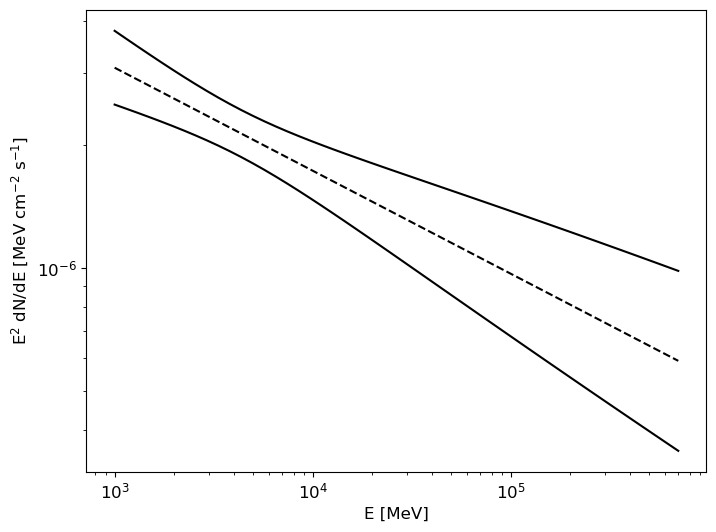

In [57]:
source_name = '4FGL J1908.6+0915e'
E = np.array(c['sources'][source_name]['model_flux']['energies'])
dnde = np.array(c['sources'][source_name]['model_flux']['dnde'])
dnde_hi = np.array(c['sources'][source_name]['model_flux']['dnde_hi'])
dnde_lo = np.array(c['sources'][source_name]['model_flux']['dnde_lo'])


plt.clf()
plt.loglog(E, (E**2)*dnde, 'k--')
plt.loglog(E, (E**2)*dnde_hi, 'k')
plt.loglog(E, (E**2)*dnde_lo, 'k')
plt.xlabel('E [MeV]')
plt.ylabel(r'E$^2$ dN/dE [MeV cm$^{-2}$ s$^{-1}$]')
plt.show()

In [60]:
sed = gta.sed(source_name)

2025-04-30 15:15:13 INFO    GTAnalysis.sed(): Computing SED for 4FGL J1908.6+0915e
2025-04-30 15:15:39 INFO    GTAnalysis._make_sed(): Fitting SED
2025-04-30 15:15:39 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1908.6+0915e    : ['Index']
2025-04-30 15:15:39 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1910.2+0904c    : ['Index']
2025-04-30 15:15:39 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1911.0+0905     : ['alpha', 'beta']
2025-04-30 15:15:39 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1911.8+0903c    : ['Index']
2025-04-30 15:15:39 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1912.0+0927     : ['alpha', 'beta']
2025-04-30 15:15:39 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1908.7+0812     : ['alpha', 'beta']
2025-04-30 15:15:39 INFO    GTAnalysis.free_source(): Fixing parameters for 4FGL J1913.3+0905     : ['IndexS', 'ExpfactorS']
2025-04-30 15:15:39 INFO    GTAnalysis.free_

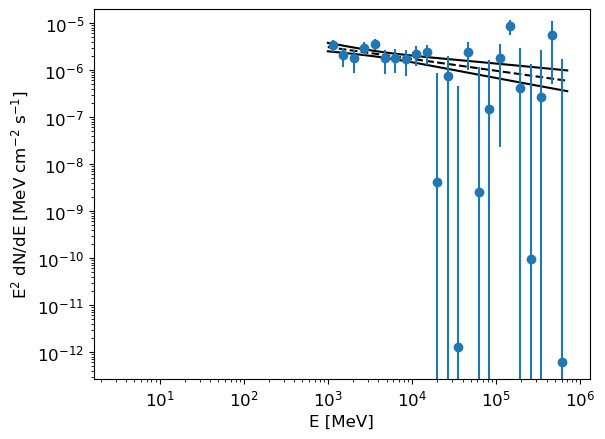

In [61]:
plt.clf()
plt.loglog(E, (E**2)*dnde, 'k--')
plt.loglog(E, (E**2)*dnde_hi, 'k')
plt.loglog(E, (E**2)*dnde_lo, 'k')
plt.errorbar(np.array(sed['e_ctr']),
             sed['e2dnde'],
             yerr=sed['e2dnde_err'], fmt ='o')
plt.xlabel('E [MeV]')
plt.ylabel(r'E$^{2}$ dN/dE [MeV cm$^{-2}$ s$^{-1}$]')
plt.show()

## Plot the counts cube file

Filename: /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/ccube.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      27   (300, 300, 23)   float32   
  1  EBOUNDS       1 BinTableHDU     22   23R x 4C   [K, D, D, D]   


<Figure size 640x480 with 0 Axes>

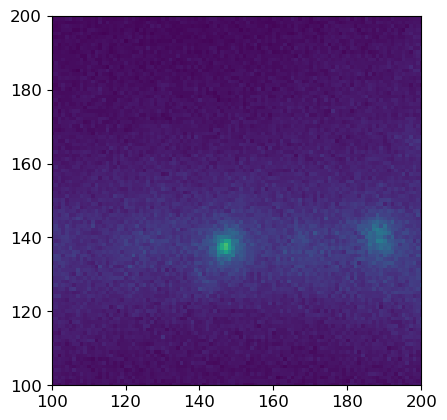

In [ ]:
import astropy.io.fits as pyfits

h = pyfits.open('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/ccube.fits')
h.info()
counts = h[0].data
counts.shape
plt.clf()
plt.figure()
plt.imshow(np.sum(counts,axis=0),interpolation='nearest',origin='lower')

plt.show()

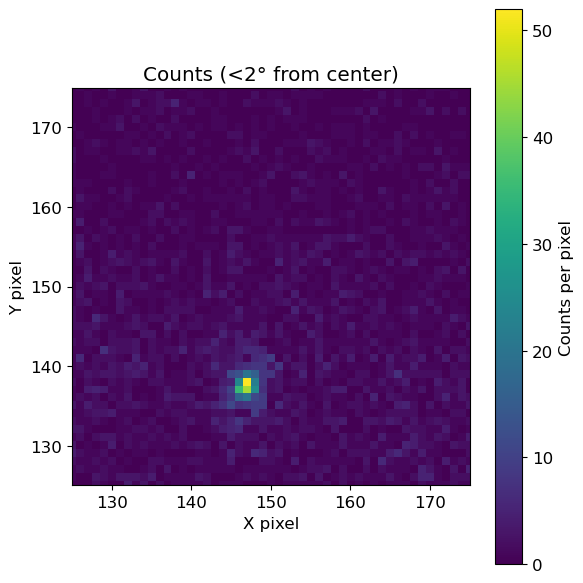

In [51]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.io.fits as fits

# 1) Load the cube and build counts2d as before
h       = fits.open('/Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/ccube.fits')
counts3d = h[0].data        # shape = (n_ebins, ny, nx)
ebounds  = h[1].data
# 2) choose your energy band (MeV)
Emin, Emax = 10000.0, 1000000.0

# 3) build a mask of the bins you want
#    column names might be 'E_MIN' / 'E_MAX' or 'ENERG_LO' / 'ENERG_HI'
emin_arr = ebounds['E_MIN']  # lower edge of each channel
emax_arr = ebounds['E_MAX']  # upper edge
mask = (emax_arr > Emin) & (emin_arr < Emax)

# 4) sum over only those energy slices
counts2d = counts3d[mask, :, :].sum(axis=0)

# 2) Figure out the pixel scale in degrees/pix
hdr   = h[0].header
# CDELT1 = ΔRA per pixel (often negative), CDELT2 = ΔDec per pixel
pixscale = abs(hdr['CDELT1'])   # deg / pixel

# 3) Compute the radius in pixels
radius_deg = 2.0
radius_pix = radius_deg / pixscale

# 4) Get the center pixel indices
ny, nx = counts2d.shape
cy, cx = ny//2, nx//2

# 5) Build a circular mask
y, x = np.ogrid[:ny, :nx]
dist2 = (x - cx)**2 + (y - cy)**2
mask  = dist2 <= radius_pix**2

# 6) Zero‐out everything outside the circle (or set to nan)
circular_map = np.zeros_like(counts2d)
circular_map[mask] = counts2d[mask]

# 7) Display
plt.figure(figsize=(6,6))
plt.imshow(circular_map, origin='lower', interpolation='nearest')
plt.title(f'Counts (<2° from center)')
plt.xlabel('X pixel'); plt.ylabel('Y pixel')
plt.colorbar(label='Counts per pixel')
plt.xlim(125, 175)
plt.ylim(125, 175)
plt.tight_layout()
plt.show()

In [42]:
counts3d

array([[[2., 1., 2., ..., 0., 0., 1.],
        [0., 1., 2., ..., 3., 3., 1.],
        [0., 1., 1., ..., 0., 0., 2.],
        ...,
        [1., 3., 1., ..., 1., 1., 1.],
        [2., 1., 1., ..., 2., 1., 2.],
        [2., 3., 4., ..., 1., 2., 0.]],

       [[1., 0., 1., ..., 0., 1., 0.],
        [0., 1., 2., ..., 1., 1., 0.],
        [0., 0., 0., ..., 1., 2., 1.],
        ...,
        [0., 0., 5., ..., 2., 2., 2.],
        [0., 0., 1., ..., 0., 1., 3.],
        [0., 1., 2., ..., 1., 1., 0.]],

       [[0., 2., 1., ..., 0., 1., 0.],
        [1., 1., 1., ..., 1., 1., 0.],
        [0., 0., 1., ..., 0., 0., 2.],
        ...,
        [0., 0., 0., ..., 1., 1., 1.],
        [1., 0., 0., ..., 1., 1., 0.],
        [1., 0., 1., ..., 0., 0., 1.]],

       ...,

       [[0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        ...,
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0., 0.],
        [0., 0., 0., ..., 0., 0.

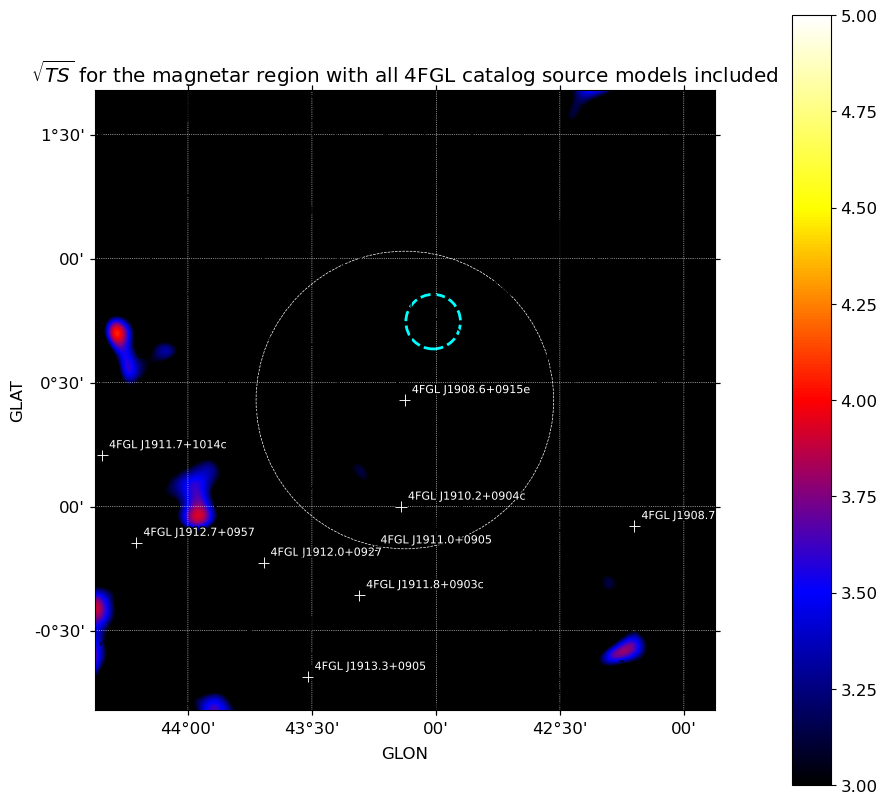

In [13]:
p = ROIPlotter(tsmap_postfit['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=10.0)  # optional threshold for labeling

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")

plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=6,vmin=3,vmax=5, levels=[0,3,5])
p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')
plt.title("$\sqrt{TS}$ for the magnetar region with all 4FGL catalog source models included")
plt.show()

### Excluded source

In [208]:
for source in gta.roi.sources:
    print(source)

Name           : 4FGL J1908.6+0915e
Associations   : ['4FGL J1908.6+0915e', 'SNR G042.8+00.6']
RA/DEC         :    287.160/     9.260
GLON/GLAT      :     43.125/     0.430
TS             : 84.07
Npred          : 1847.27
Flux           : 2.834e-09 +/-  4.1e-10
EnergyFlux     : 1.056e-05 +/- 1.79e-06
SpatialModel   : RadialDisk
SpectrumType   : PowerLaw
Spectral Parameters
b'Prefactor'   :  1.361e-13 +/-  1.739e-14
b'Index'       :       -2.3 +/-     0.1208
b'Scale'       :       4196 +/-        nan
Name           : 4FGL J1910.2+0904c
Associations   : ['4FGL J1910.2+0904c', 'G42.8+0.6 field', '2AGL J1911+0907']
RA/DEC         :    287.553/     9.076
GLON/GLAT      :     43.141/     0.000
TS             : 238.44
Npred          : 1993.66
Flux           : 3.066e-09 +/- 4.27e-10
EnergyFlux     : 1.018e-05 +/- 1.02e-06
SpatialModel   : PointSource
SpectrumType   : PowerLaw
Spectral Parameters
b'Prefactor'   :  4.127e-14 +/-  4.056e-15
b'Index'       :     -2.382 +/-     0.0927
b'Scale'      

In [165]:
plt.clf()
plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
tsmap_excluded = gta.tsmap(prefix='TSmap_excluded',make_plots=True,write_fits=True,write_npy=True,
                           exclude=gta.roi.sources[0].name)

2025-04-28 14:40:27 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-28 14:40:30 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-28 14:41:22 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-28 14:41:24 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/TSmap_excluded_pointsource_powerlaw_2.00_tsmap.npy
2025-04-28 14:41:24 INFO    GTAnalysis.tsmap(): Execution time: 57.32 s


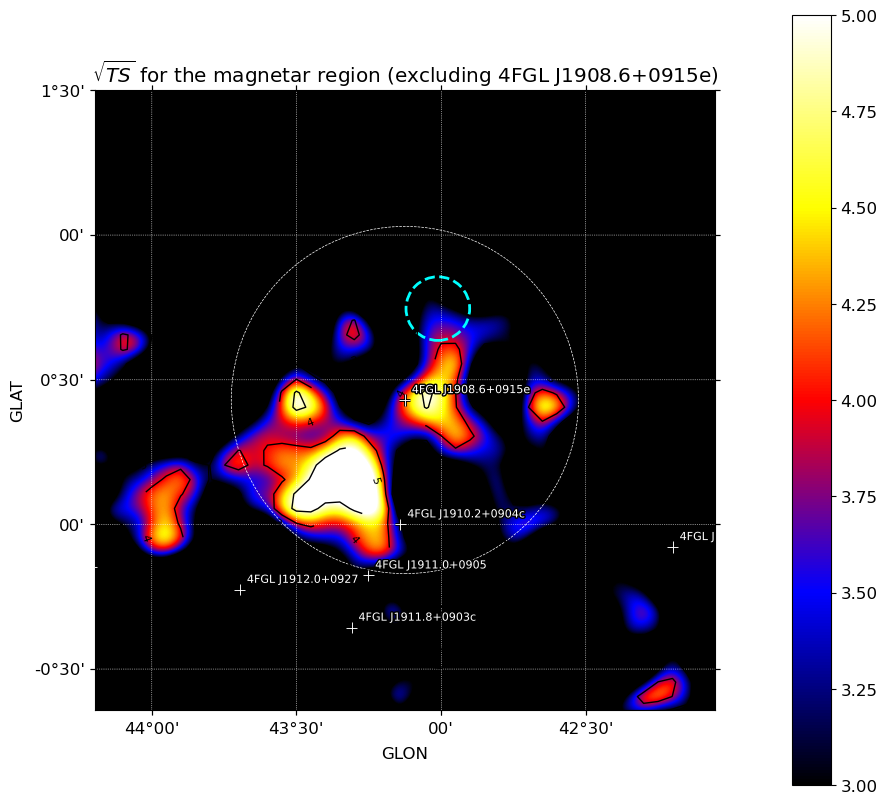

In [189]:
p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=10)  # optional threshold for labeling
plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=7,vmin=3,vmax=5, levels=[3,4,5])
from astropy.coordinates import SkyCoord

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")
circle_pos = SkyCoord(ra=gta.roi.sources[0]['ra'], dec=gta.roi.sources[0]['dec'], unit='deg', frame='icrs')  # example coords

p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')
plt.title("$\sqrt{TS}$ for the magnetar region (excluding 4FGL J1908.6+0915e)")
plt.show()

2025-04-28 14:28:01 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-28 14:28:05 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-28 14:28:59 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-28 14:29:01 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/TSmap_excluded_pointsource_powerlaw_2.00_tsmap.npy
2025-04-28 14:29:01 INFO    GTAnalysis.tsmap(): Execution time: 60.34 s


<Figure size 640x480 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

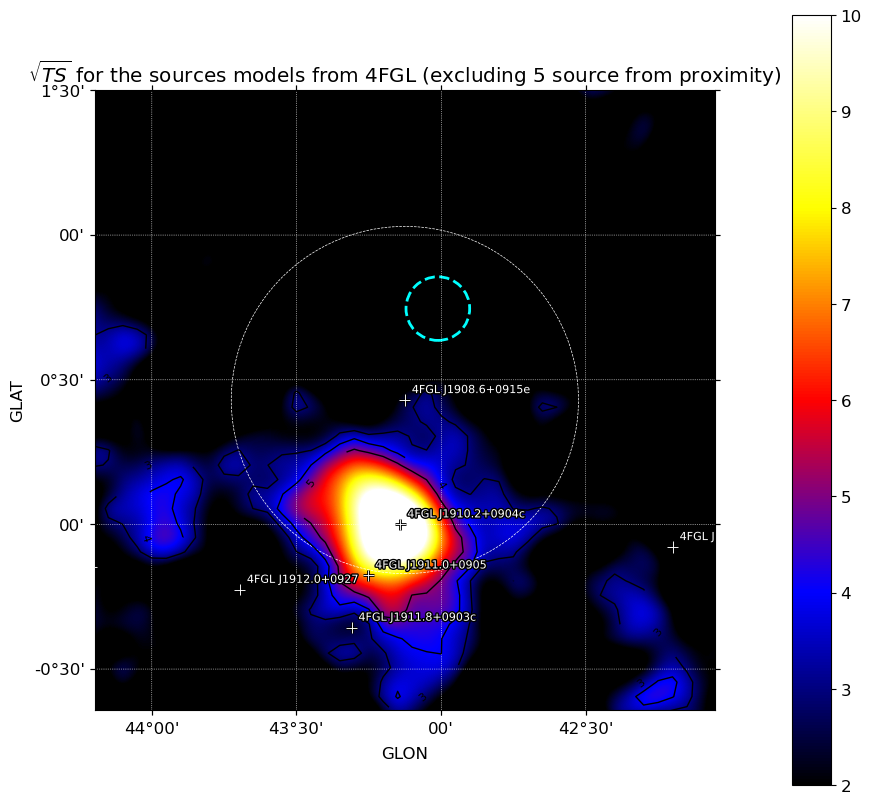

In [157]:
plt.clf()
plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
tsmap_excluded = gta.tsmap(prefix='TSmap_excluded',make_plots=True,write_fits=True,write_npy=True,
                           exclude=gta.roi.sources[1].name)

p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=0)  # optional threshold for labeling
plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=7,vmin=2,vmax=10, levels=[3,4,5])
from astropy.coordinates import SkyCoord

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")
circle_pos = SkyCoord(ra=gta.roi.sources[0]['ra'], dec=gta.roi.sources[0]['dec'], unit='deg', frame='icrs')  # example coords

p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')
plt.title("$\sqrt{TS}$ for the sources models from 4FGL (excluding 5 source from proximity)")
plt.show()

2025-04-28 13:42:32 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-28 13:42:36 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-28 13:43:31 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-28 13:43:33 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/TSmap_excluded_pointsource_powerlaw_2.00_tsmap.npy
2025-04-28 13:43:33 INFO    GTAnalysis.tsmap(): Execution time: 60.30 s


<Figure size 640x480 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

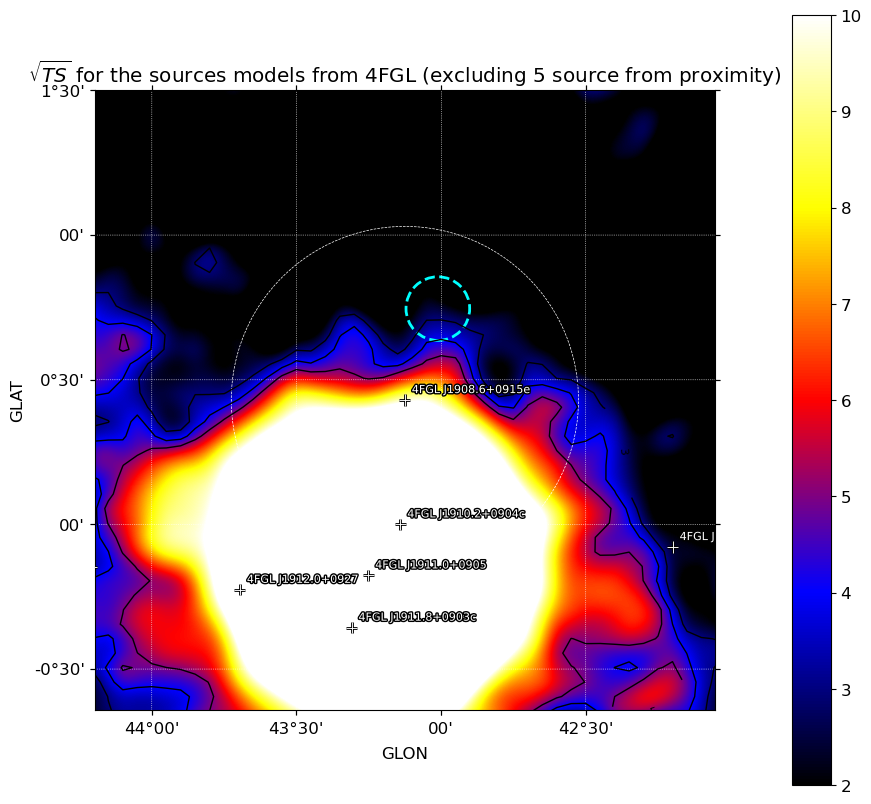

In [138]:
plt.clf()
plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
tsmap_excluded = gta.tsmap(prefix='TSmap_excluded',make_plots=True,write_fits=True,write_npy=True,
                           exclude=["4FGL J1911.0+0905","4FGL J1910.2+0904c"])

p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=0)  # optional threshold for labeling
plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=7,vmin=2,vmax=10, levels=[3,4,5])
from astropy.coordinates import SkyCoord

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")
circle_pos = SkyCoord(ra=gta.roi.sources[0]['ra'], dec=gta.roi.sources[0]['dec'], unit='deg', frame='icrs')  # example coords

p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')
plt.title("$\sqrt{TS}$ for the sources models from 4FGL (excluding 5 source from proximity)")
plt.show()

2025-04-28 14:07:53 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-28 14:07:56 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-28 14:08:52 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-28 14:08:54 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/TSmap_excluded_pointsource_powerlaw_2.00_tsmap.npy
2025-04-28 14:08:54 INFO    GTAnalysis.tsmap(): Execution time: 61.66 s


<Figure size 640x480 with 0 Axes>

<Figure size 1000x1000 with 0 Axes>

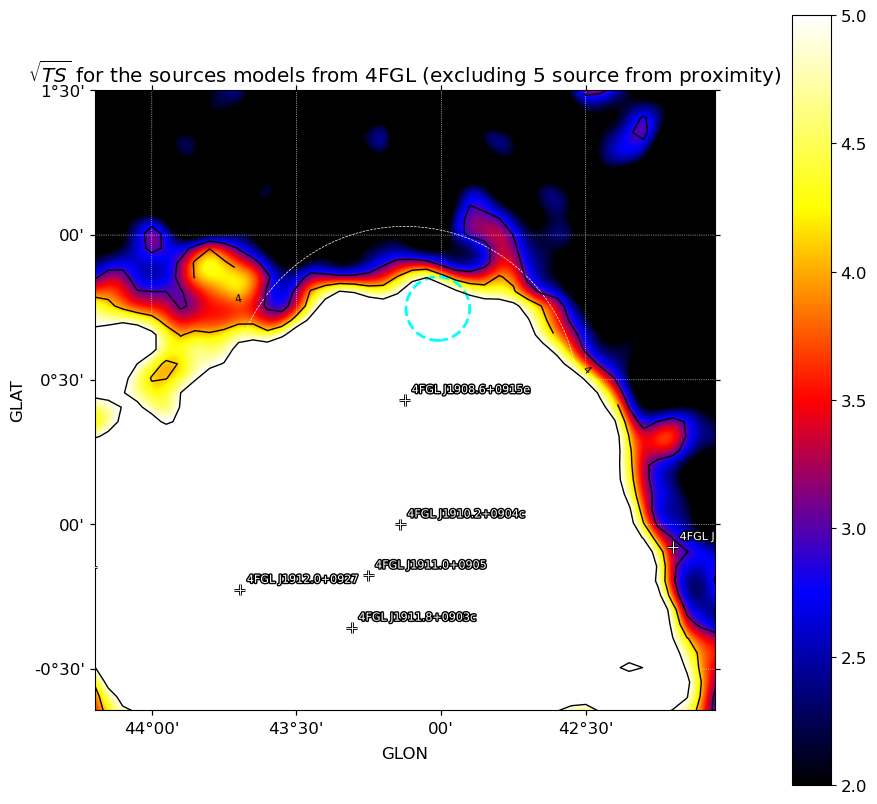

In [153]:
plt.clf()
plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
tsmap_excluded = gta.tsmap(prefix='TSmap_excluded',make_plots=True,write_fits=True,write_npy=True,
                           exclude=["4FGL J1911.0+0905","4FGL J1910.2+0904c", "4FGL J1911.8+0903c", "4FGL J1912.0+0927", "4FGL J1908.6+0915e"])

p = ROIPlotter(tsmap_excluded['sqrt_ts'], roi=gta.roi, 
               cmap='ds9_b',   # example colormap
               graticule_radii=[0.6],  # optional, for overlaying circles
               label_ts_threshold=0)  # optional threshold for labeling
plt.figure(figsize=(10, 10))  # e.g., 10x10 inches
p.plot(interpolation='bicubic', zoom=7,vmin=2,vmax=5, levels=[3,4,5])
from astropy.coordinates import SkyCoord

snr_g_043 = SkyCoord(43.011, 0.746, unit="deg", frame="galactic")
circle_pos = SkyCoord(ra=gta.roi.sources[0]['ra'], dec=gta.roi.sources[0]['dec'], unit='deg', frame='icrs')  # example coords

p.draw_circle(0.11,  # radius in degrees
              skydir=snr_g_043,
              edgecolor='cyan',
              linewidth=2.0,
              linestyle='--')
plt.title("$\sqrt{TS}$ for the sources models from 4FGL (excluding 5 source from proximity)")
plt.show()

# Tryting to distinguish 2 sources

In [156]:
tsmap_test = gta.tsmap(xmax=0.6, step=0.02)

KeyError: 'Invalid configuration key: xmax'

<Figure size 640x480 with 0 Axes>

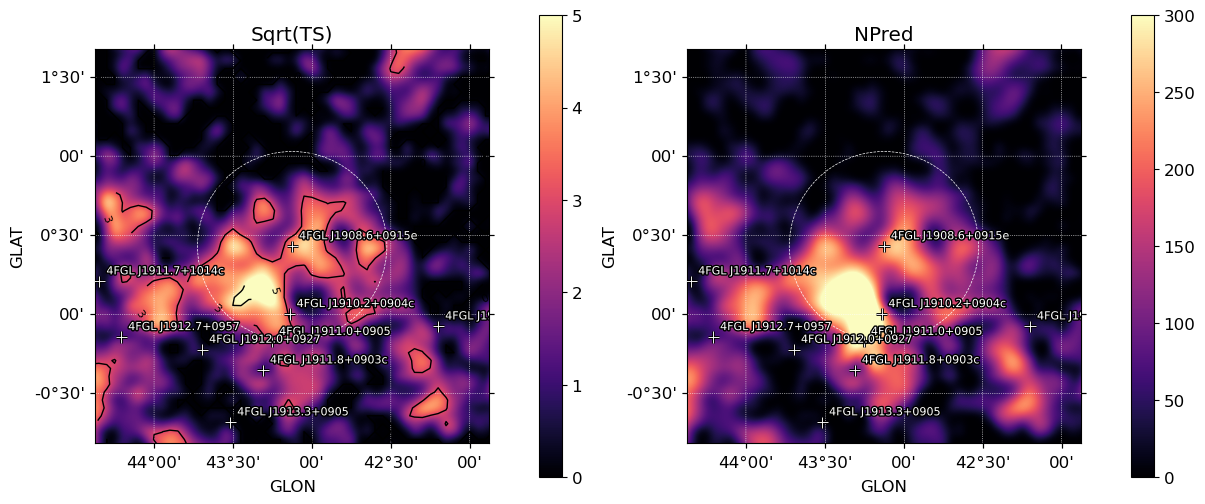

In [88]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(tsmap_excluded['sqrt_ts'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',levels=[0,3,5],vmin=0,vmax=5,subplot=121,cmap='magma', zoom = 6)
plt.gca().set_title('Sqrt(TS)')
ROIPlotter(tsmap_excluded['npred'],roi=gta.roi, graticule_radii=[0.6]).plot(interpolation='bicubic',vmin=0,vmax=300,subplot=122,cmap='magma', zoom = 6)
plt.gca().set_title('NPred')
plt.show()

# Finding source

In [91]:
model = {'Index' : 2.0, 'SpatialModel' : 'PointSource'}
srcs = gta.find_sources(model=model, sqrt_ts_threshold=5.0,
                        min_separation=0.5)

2025-04-16 13:51:25 INFO    GTAnalysis.find_sources(): Starting.
2025-04-16 13:51:25 INFO    GTAnalysis.tsmap(): Generating TS map
2025-04-16 13:51:29 INFO    GTAnalysis._make_tsmap_fast(): Fitting test source.
2025-04-16 13:52:24 INFO    GTAnalysis.tsmap(): Finished TS map
2025-04-16 13:52:26 WARNING GTAnalysis.tsmap(): Saving TS maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/sourcefind_00_pointsource_powerlaw_2.00_tsmap.npy
2025-04-16 13:52:26 INFO    GTAnalysis.tsmap(): Execution time: 60.71 s
2025-04-16 13:52:26 INFO    GTAnalysis._build_src_dicts_from_peaks(): Found source
name: PS J1857.8+0214
ts: 175.350350
2025-04-16 13:52:26 INFO    GTAnalysis._build_src_dicts_from_peaks(): Found source
name: PS J1922.8+1412
ts: 64.009086
2025-04-16 13:52:26 INFO    GTAnalysis._build_src_dicts_from_peaks(): Found source
name: PS J1858.9+0339
ts: 32.8

In [76]:
gta.roi.sources[0]['ra']

287.16

# Residual Map

In [57]:
gta.print_model()

2025-04-16 12:57:07 INFO    GTAnalysis.print_model(): 
sourcename            offset    norm  eflux     index        ts       npred free
--------------------------------------------------------------------------------
4FGL J1908.6+0915e     0.000   1.228  9.92e-06   2.26     66.58      1620.5    *
4FGL J1910.2+0904c     0.430   0.413  1.02e-05   2.38    238.23      2004.6    *
4FGL J1911.0+0905      0.619   0.692  5.41e-05   2.19   6336.50     10392.3    *
4FGL J1911.8+0903c     0.808   0.531  5.66e-06   2.34     70.85      1053.3    *
4FGL J1912.0+0927      0.869   0.325  3.89e-06   2.74     84.00      1170.5    *
4FGL J1908.7+0812      1.056   1.723  6.63e-06   3.20    233.61      2324.9    *
4FGL J1913.3+0905      1.183   0.785  6.34e-06   3.28    324.91      1827.1    *
4FGL J1912.7+0957      1.226   0.488  4.87e-06   2.85    149.53      1518.7    *
4FGL J1911.7+1014c     1.241   0.333  3.27e-06   2.97     47.55       851.2    *
4FGL J1913.3+1019      1.586   0.326  7.33e-06   2.18 

In [62]:
resid = gta.residmap('SGR_postfit',model={'SpatialModel' : 'PointSource', 'Index' : 2.26},write_fits=True,write_npy=True,make_plots=True)

2025-04-16 12:58:10 INFO    GTAnalysis.residmap(): Generating residual maps
2025-04-16 12:58:10 INFO    GTAnalysis.add_source(): Adding source residmap_testsource
2025-04-16 12:58:12 INFO    GTAnalysis.delete_source(): Deleting source residmap_testsource
2025-04-16 12:58:14 INFO    GTAnalysis.residmap(): Finished residual maps
2025-04-16 12:58:16 WARNING GTAnalysis.residmap(): Saving maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_15deg_region/SGR_postfit_pointsource_powerlaw_2.26_residmap.npy
2025-04-16 12:58:16 INFO    GTAnalysis.residmap(): Execution time: 6.05 s


<Figure size 640x480 with 0 Axes>

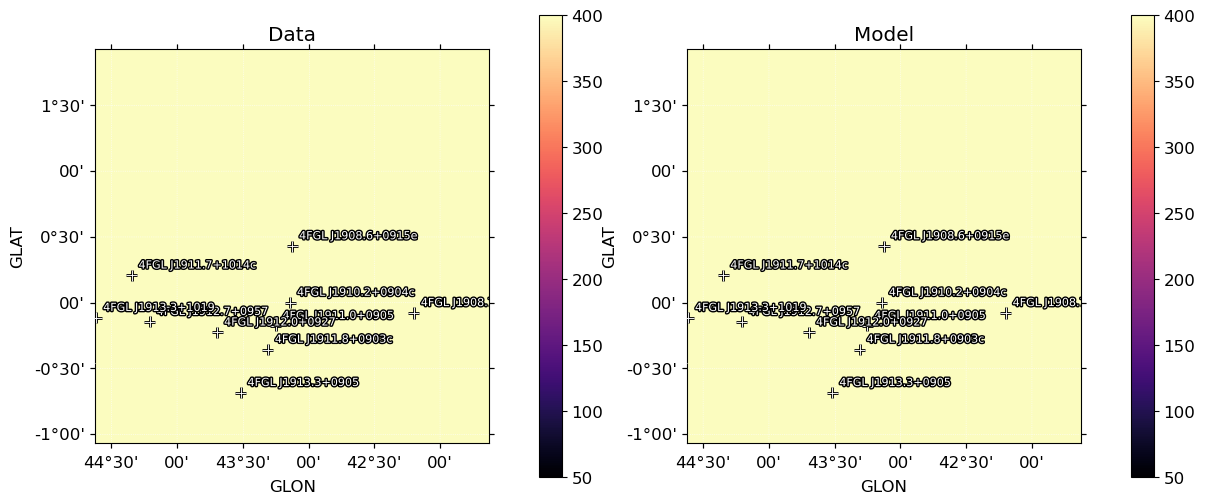

In [63]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(resid['data'],roi=gta.roi).plot(vmin=50,vmax=400,subplot=121,cmap='magma', zoom=5)
plt.gca().set_title('Data')
ROIPlotter(resid['model'],roi=gta.roi).plot(vmin=50,vmax=400,subplot=122,cmap='magma', zoom=5)
plt.gca().set_title('Model')
plt.show()

In [29]:
resid_config = {
    'model': {
        # Optionally, adjust the test source configuration if needed.
        'SpatialModel': 'Gaussian',  # or appropriate for your source
        'SpatialWidth': 0.5,         # extension in degrees
        'Index': 2.0,
        'Prefactor': 1E-13,
    },
    'loge_bounds': [1, 10],  # set your energy range
    'make_plots': True,
    'write_fits': True,
    # You can add other configuration options here.
}

# Exclude a list of sources from the model. For instance, exclude the SNR:
resid_map = gta.residmap(prefix="resid_excluded", exclude=gta.roi.sources[0].name, **resid_config)

2025-04-16 13:36:05 INFO    GTAnalysis.residmap(): Generating residual maps
2025-04-16 13:36:05 INFO    GTAnalysis.add_source(): Adding source residmap_testsource
2025-04-16 13:36:06 INFO    GTAnalysis.delete_source(): Deleting source residmap_testsource
2025-04-16 13:36:08 INFO    GTAnalysis.residmap(): Finished residual maps
2025-04-16 13:36:10 WARNING GTAnalysis.residmap(): Saving maps in .npy files is disabled b/c of incompatibilities in python3, remove the maps from the /Users/vdk/software/my_codebase/python/data_analysis/fermi_lat/sgr1900/output_sgr_1GeV_15deg_region/resid_excluded_gaussian_s0.50_powerlaw_2.00_residmap.npy
2025-04-16 13:36:10 INFO    GTAnalysis.residmap(): Execution time: 4.78 s


<Figure size 640x480 with 0 Axes>

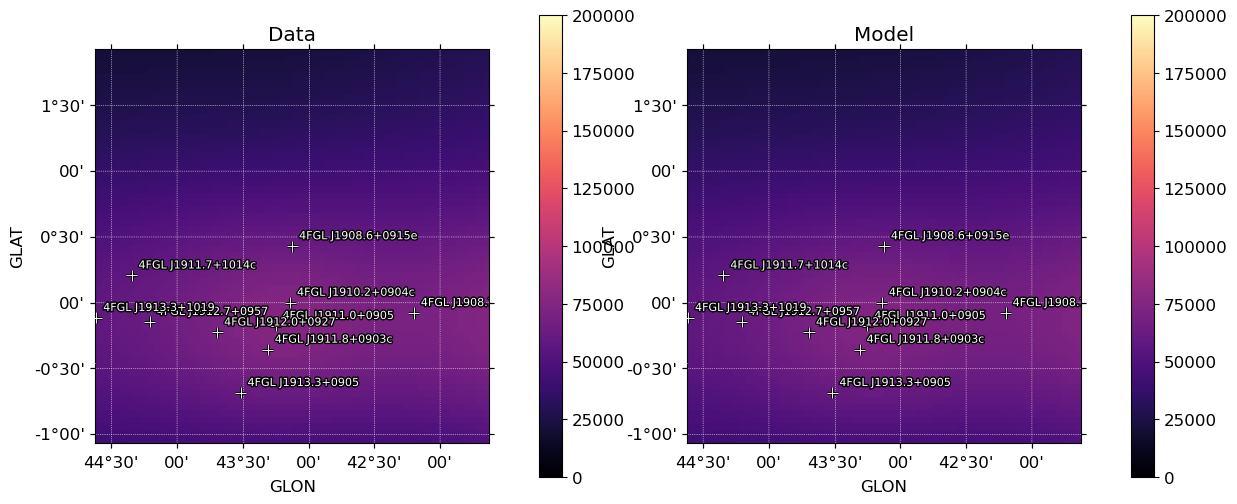

In [42]:
plt.clf()
fig = plt.figure(figsize=(14,6))
ROIPlotter(resid_map['data'],roi=gta.roi).plot(vmin=0,vmax=200000,subplot=121,cmap='magma', zoom=5)
plt.gca().set_title('Data')
ROIPlotter(resid_map['model'],roi=gta.roi).plot(vmin=0,vmax=200000,subplot=122,cmap='magma', zoom=5)
plt.gca().set_title('Model')
plt.show()

In [ ]:
import fermipy
fermipy.__path__

['/Users/vdk/miniforge3/envs/fermipy/lib/python3.9/site-packages/fermipy']

In [13]:
for src_info in gta.roi.sources:
    print(src_info)

Name           : 4FGL J1908.6+0915e
Associations   : ['4FGL J1908.6+0915e', 'SNR G042.8+00.6']
RA/DEC         :    287.160/     9.260
GLON/GLAT      :     43.125/     0.430
TS             : nan
Npred          : 1631.64
Flux           : 2.497e-09 +/-      nan
EnergyFlux     : 1.091e-05 +/-      nan
SpatialModel   : RadialDisk
SpectrumType   : PowerLaw
Spectral Parameters
b'Prefactor'   :  1.276e-13 +/-        nan
b'Index'       :     -2.201 +/-        nan
b'Scale'       :       4196 +/-        nan
Name           : 4FGL J1910.2+0904c
Associations   : ['4FGL J1910.2+0904c', 'G42.8+0.6 field', '2AGL J1911+0907']
RA/DEC         :    287.553/     9.076
GLON/GLAT      :     43.141/     0.000
TS             : nan
Npred          : 1715.88
Flux           : 2.633e-09 +/-      nan
EnergyFlux     : 9.923e-06 +/-      nan
SpatialModel   : PointSource
SpectrumType   : PowerLaw
Spectral Parameters
b'Prefactor'   :  3.945e-14 +/-        nan
b'Index'       :     -2.292 +/-        nan
b'Scale'       :   

In [163]:
arcmin = 30 * u.arcmin
arcmin.to(u.deg).value
deg = 0.75 * u.deg
deg.to(u.arcmin).value

45.0